# Normalized radial FFT spectrum (STAL-compatible)

This notebook reproduces the radial log-power preprocessing used by the STAL frequency teacher. Change `IMAGE_PATH` in the settings cell, then run all cells. Set `COMPARE_DEGRADED = True` to overlay deterministic heavy blur and JPEG transformations.

In [26]:
%matplotlib inline

import io
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from IPython.display import display
from torchvision import transforms
import torchvision.transforms.functional as TF
from scipy.interpolate import PchipInterpolator

# Change this path.
IMAGE_PATH = Path("/home/utakata/LLMs/techjam2026/SID/real/0000025.jpg")

SIZE = 224
NUM_BINS = 64
TAIL_START = 0.70

# Set to False to plot only the original image.
COMPARE_DEGRADED = True
BLUR_SIGMA = 2.0
JPEG_QUALITY = 30

# Optional file output. Set to None to display without saving.
SAVE_PLOT_PATH = None  # Example: Path("plots/example_fft.png")

def load_rgb_image(path):
    with Image.open(path) as source:
        source.load()
        has_transparency = (
            source.mode in {"RGBA", "LA"}
            or (source.mode == "P" and "transparency" in source.info)
        )
        if has_transparency:
            rgba = source.convert("RGBA")
            background = Image.new("RGBA", rgba.size, (255, 255, 255, 255))
            return Image.alpha_composite(background, rgba).convert("RGB")
        return source.convert("RGB")


def jpeg_compress(image, quality):
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    with Image.open(buffer) as compressed:
        compressed.load()
        return compressed.convert("RGB")


def gaussian_blur(image, sigma):
    kernel_size = max(3, 2 * int(3 * sigma) + 1)
    return TF.gaussian_blur(image, kernel_size=kernel_size, sigma=sigma)


def radial_log_power_spectrum(image, num_bins=64, eps=1e-6):
    # This matches RadialLogPowerSpectrum in model.py.
    images = TF.to_tensor(image).unsqueeze(0).float()
    luminance = (
        0.299 * images[:, 0]
        + 0.587 * images[:, 1]
        + 0.114 * images[:, 2]
    )
    luminance = luminance - luminance.mean(dim=(-2, -1), keepdim=True)

    height, width = luminance.shape[-2:]
    window_y = torch.hann_window(height, periodic=False, dtype=images.dtype)
    window_x = torch.hann_window(width, periodic=False, dtype=images.dtype)
    window = window_y[:, None] * window_x[None, :]

    spectrum = torch.fft.fft2(luminance * window, norm="ortho")
    spectrum = torch.fft.fftshift(spectrum, dim=(-2, -1))
    log_power = torch.log(spectrum.abs().square() + 1e-12)

    y = torch.arange(height, dtype=images.dtype) - (height - 1) / 2
    x = torch.arange(width, dtype=images.dtype) - (width - 1) / 2
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    radius = torch.sqrt(yy.square() + xx.square())
    radius = radius / radius.max().clamp_min(eps)

    bin_index = torch.clamp(
        (radius * num_bins).long(), min=0, max=num_bins - 1
    ).reshape(1, -1)
    radial_sum = torch.zeros(1, num_bins, dtype=log_power.dtype)
    radial_sum.scatter_add_(1, bin_index, log_power.reshape(1, -1))
    counts = torch.bincount(bin_index[0], minlength=num_bins).to(log_power.dtype)
    radial = radial_sum / counts.clamp_min(1).unsqueeze(0)

    normalized = radial - radial.mean(dim=1, keepdim=True)
    normalized = normalized / normalized.std(
        dim=1, keepdim=True
    ).clamp_min(eps)

    return (
        radial.squeeze(0).numpy(),
        normalized.squeeze(0).numpy(),
        counts.numpy(),
    )


def tail_statistics(normalized_spectrum, tail_bin, x_coordinates):
    tail = normalized_spectrum[tail_bin:]
    tail_x = x_coordinates[tail_bin:]
    slope = float(np.polyfit(tail_x, tail, deg=1)[0]) if len(tail) >= 2 else 0.0
    return {
        "mean": float(tail.mean()),
        "std": float(tail.std()),
        "minimum": float(tail.min()),
        "maximum": float(tail.max()),
        "slope": slope,
    }

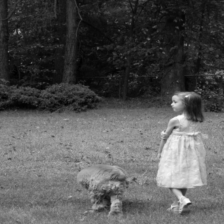

original: tail mean=-0.9689, std=0.1724, slope=-1.8864
blur sigma=2: tail mean=-0.5625, std=0.0624, slope=-0.4340
JPEG quality=30: tail mean=-1.0493, std=0.1944, slope=-2.1266
blur + JPEG: tail mean=-0.8909, std=0.0999, slope=-0.8775


In [27]:
if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"Image does not exist: {IMAGE_PATH}")

image = load_rgb_image(IMAGE_PATH)
image = transforms.Resize((SIZE, SIZE), antialias=True)(image)
display(image)

variants = {"original": image}
if COMPARE_DEGRADED:
    blurred = gaussian_blur(image, BLUR_SIGMA)
    compressed = jpeg_compress(image, JPEG_QUALITY)
    variants.update({
        f"blur sigma={BLUR_SIGMA:g}": blurred,
        f"JPEG quality={JPEG_QUALITY}": compressed,
        "blur + JPEG": jpeg_compress(blurred, JPEG_QUALITY),
    })

bin_centers = (np.arange(NUM_BINS) + 0.5) / NUM_BINS
tail_bin = min(NUM_BINS - 1, int(round(NUM_BINS * TAIL_START)))
tail_boundary = tail_bin / NUM_BINS

results = {}
for name, variant in variants.items():
    raw, normalized, counts = radial_log_power_spectrum(variant, NUM_BINS)
    results[name] = {
        "raw": raw,
        "normalized": normalized,
        "counts": counts,
        "tail_statistics": tail_statistics(normalized, tail_bin, bin_centers),
    }

for name, values in results.items():
    stats = values["tail_statistics"]
    print(
        f"{name}: tail mean={stats['mean']:.4f}, "
        f"std={stats['std']:.4f}, slope={stats['slope']:.4f}"
    )

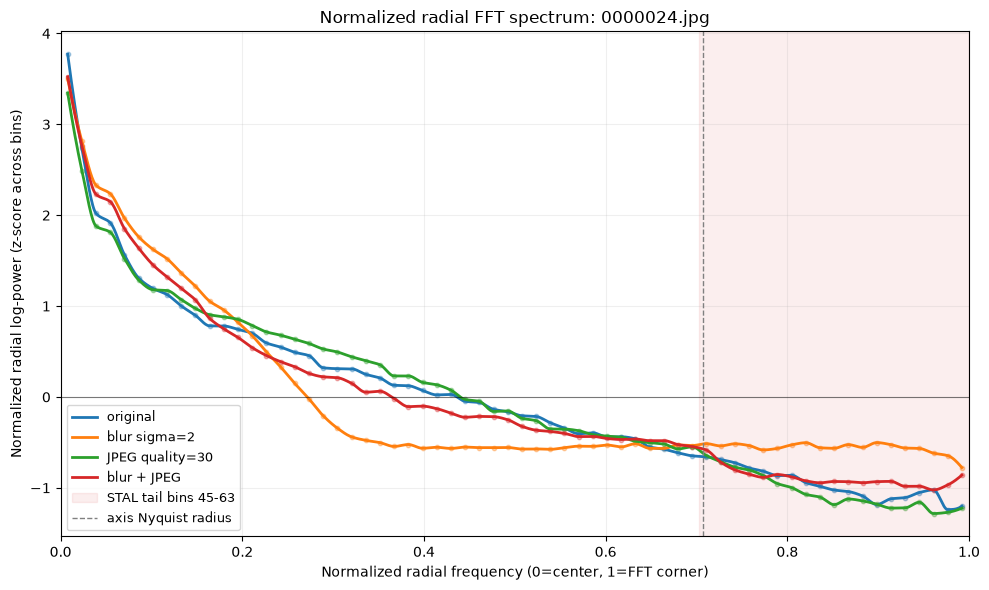

In [28]:
fig, axis = plt.subplots(figsize=(10, 6))
for name, values in results.items():
    y = values["normalized"]

    dense_x = np.linspace(
        bin_centers[0],
        bin_centers[-1],
        1000,
    )
    
    dense_y = PchipInterpolator(
        bin_centers,
        y,
    )(dense_x)
    
    # Smooth interpolated curve
    axis.plot(
        dense_x,
        dense_y,
        linewidth=2,
        label=name,
    )
    
    # Show the actual 64 measurements
    axis.scatter(
        bin_centers,
        y,
        s=10,
        alpha=0.35,
    )

axis.axhline(0, color="black", linewidth=0.8, alpha=0.5)
axis.axvspan(
    tail_boundary, 1.0, color="tab:red", alpha=0.08,
    label=f"STAL tail bins {tail_bin}-{NUM_BINS - 1}",
)
axis.axvline(
    1 / math.sqrt(2), color="gray", linestyle="--", linewidth=1,
    label="axis Nyquist radius",
)
axis.set_xlim(0, 1)
axis.set_xlabel("Normalized radial frequency (0=center, 1=FFT corner)")
axis.set_ylabel("Normalized radial log-power (z-score across bins)")
axis.set_title(f"Normalized radial FFT spectrum: {IMAGE_PATH.name}")
axis.grid(alpha=0.2)
axis.legend(fontsize=9)
fig.tight_layout()

if SAVE_PLOT_PATH is not None:
    SAVE_PLOT_PATH = Path(SAVE_PLOT_PATH)
    SAVE_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_PLOT_PATH, dpi=200, bbox_inches="tight")
    print(f"Saved to {SAVE_PLOT_PATH}")

plt.show()

## Optional: inspect raw radial log-power

The normalized curve can hide the loss of absolute high-frequency energy under blur. The raw plot below is useful when judging whether the tail remains reliable.

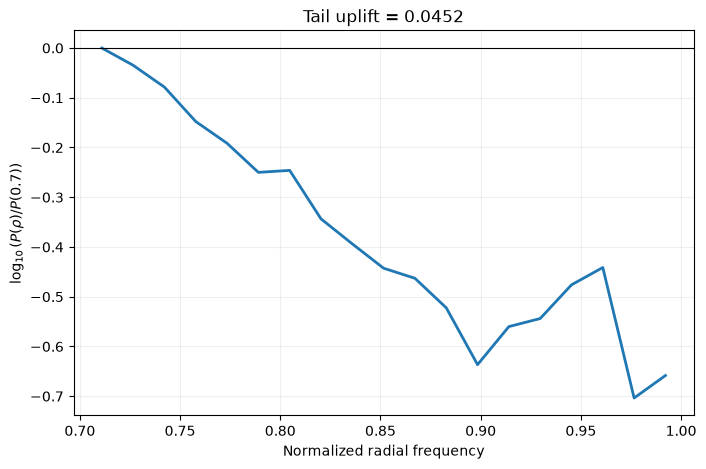

In [29]:
raw = results["original"]["raw"]

tail_x = bin_centers[tail_bin:]
tail_curve = (
    raw[tail_bin:] - raw[tail_bin]
) / np.log(10)

uplift = tail_curve[-1] - tail_curve.min()

plt.figure(figsize=(8, 5))
plt.plot(tail_x, tail_curve, linewidth=2)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Normalized radial frequency")
plt.ylabel(r"$\log_{10}(P(\rho)/P(0.7))$")
plt.title(f"Tail uplift = {uplift:.4f}")
plt.grid(alpha=0.2)
plt.show()

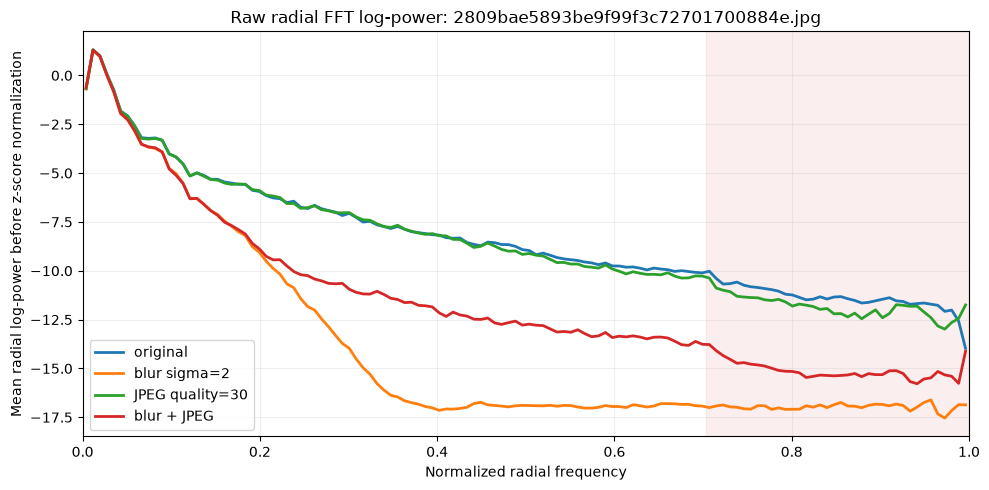

In [22]:
fig, axis = plt.subplots(figsize=(10, 5))
for name, values in results.items():
    axis.plot(bin_centers, values["raw"], linewidth=2, label=name)
axis.axvspan(tail_boundary, 1.0, color="tab:red", alpha=0.08)
axis.set_xlim(0, 1)
axis.set_xlabel("Normalized radial frequency")
axis.set_ylabel("Mean radial log-power before z-score normalization")
axis.set_title(f"Raw radial FFT log-power: {IMAGE_PATH.name}")
axis.grid(alpha=0.2)
axis.legend()
fig.tight_layout()
plt.show()